# Исследование связи времени публикации с охватом статей Хабра

## Оглавление

- [Введение](#link1)
- [Подготовка рабочего пространства](#link2)
- [1 Загрузка данных](#link3)
- [2 Предобработка данных](#link4)
- [3 Исследовательский анализ данных](#link5)
- [3.1 Анализ изменения охвата статей в течение 14 дней после публикации](#link6)
- [3.2 Анализ охвата статей за 7 дней после публикации](#link7)
- [Заключение](#link8)

<a class='anchor' id="link1"></a>
## Введение

В данном проекте проводится исследование охвата статей ленты Хабра. 

На Хабре сейчас высокая конкуренция среди авторов. По данным самого Хабра, в 2025 году на сайте было более 10 тысяч уникальных авторов контента, а количество публикаций превысило 51 тысячу [https://habr.com/ru/companies/habr/articles/978182/].

Это означает, что даже качественный материал может не получить заметный охват из-за большого количества публикаций в ленте. 

Есть распространённое мнение, что публиковать статьи нужно в предобеденное время, чтобы люди на обеденном перерыве могли почитать эти статьи, тогда охват будет максимальным. Но так как этого правила придерживаются многие, возникает высококонкурентная среда, где за час публикуются десятки статей. При этом публикации, размещённые ночью, также набирают значимый охват, несмотря на ожидаемо низкую активность пользователей в это время. 

Возникает вопрос: 

**Связано ли время публикации с охватом аудитории, и если да, то когда статьи набирают больший охват?**

### Цель исследования:

Определить временные интервалы, в которые публикации набирают больший охват.

### Описание данных:

Данные собирались автоматизировано с учётом ограничений, описанных в файле robots.txt [https://habr.com/robots.txt]. 

Для анализа использовались страницы ленты из раздела «Все потоки», вкладка «Статьи» [https://habr.com/ru/articles/].  Со страниц собиралась информация о времени публикации статьи и охвате (уникальных пользователях, открывших публикацию или увидевших её в ленте).

В итоге получилось два файла:

`df_14_days.csv` - датасет из 157 строк и 14 столбцов. Он содержит данные по 157 статьям. Для каждой статьи фиксировался охват со дня публикации до 14-го дня включительно.

`df.csv` - датасет из 2341 строки и 3 столбцов. Таблица содержит информацию о 2341 статье: название, время публикации и охват за период 156-180 часов  после публикации (6,5-7,5 дней). 

<a class='anchor' id="link2"></a>
## Подготовка рабочего пространства

In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import time
import seaborn as sns
import numpy as np
from matplotlib.ticker import AutoMinorLocator
from scipy import stats as st

from habr_analysis_utils import show_hist_boxplot, format_k

<a class='anchor' id="link3"></a>
## 1 Загрузка данных

**Загрузим датафрейм с данными по изменению охвата статей в течение 14 дней после публикации**

In [2]:
df_14_days = pd.read_csv("df_14_days.csv")

In [3]:
df_14_days.head()

,views_day1,views_day2,views_day3,views_day4,views_day5,views_day6,views_day7,views_day8,views_day9,views_day10,views_day11,views_day12,views_day13,views_day14
0,6586,7515,7901,8242,8719,9021,9172,9282,9340,9397,9455,9501,9570,9610
1,4711,5254,6089,6692,7140,7489,7661,7750,7769,7787,7806,7810,7818,7829
2,4403,4728,4862,4966,5129,5229,5258,5286,5299,5312,5325,5331,5344,5355
3,5370,5960,6274,6556,6931,7129,7227,7283,7327,7371,7415,7448,7487,7512
4,7948,8817,9206,9531,9940,10239,10419,10531,10593,10654,10716,10770,10835,10876


In [4]:
df_14_days.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   views_day1   157 non-null    int64
 1   views_day2   157 non-null    int64
 2   views_day3   157 non-null    int64
 3   views_day4   157 non-null    int64
 4   views_day5   157 non-null    int64
 5   views_day6   157 non-null    int64
 6   views_day7   157 non-null    int64
 7   views_day8   157 non-null    int64
 8   views_day9   157 non-null    int64
 9   views_day10  157 non-null    int64
 10  views_day11  157 non-null    int64
 11  views_day12  157 non-null    int64
 12  views_day13  157 non-null    int64
 13  views_day14  157 non-null    int64
dtypes: int64(14)
memory usage: 17.3 KB


In [5]:
df_14_days.describe(include="all")

,views_day1,views_day2,views_day3,views_day4,views_day5,views_day6,views_day7,views_day8,views_day9,views_day10,views_day11,views_day12,views_day13,views_day14
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.00000,157.000000,157.000000,157.000000,157.000000
mean,7581.101911,8353.292994,8744.439490,9040.694268,9273.490446,9496.261146,9638.980892,9745.369427,9801.490446,9838.89172,9871.745223,9899.777070,9940.222930,9977.324841
std,2923.279597,4145.918755,5181.912426,5993.096616,6519.986275,6895.513024,7122.601129,7299.731934,7344.602266,7370.72749,7392.965209,7417.607186,7450.765513,7480.142720
min,1433.000000,1915.000000,2111.000000,2275.000000,2351.000000,2535.000000,2659.000000,2754.000000,2809.000000,2830.00000,2851.000000,2865.000000,2878.000000,2894.000000
25%,5435.000000,5937.000000,6050.000000,6300.000000,6359.000000,6488.000000,6548.000000,6595.000000,6635.000000,6667.00000,6695.000000,6732.000000,6754.000000,6765.000000
50%,6807.000000,7373.000000,7559.000000,7729.000000,7871.000000,8025.000000,8118.000000,8186.000000,8221.000000,8234.00000,8246.000000,8260.000000,8271.000000,8294.000000
75%,9028.000000,9549.000000,9779.000000,10026.000000,10224.000000,10340.000000,10440.000000,10553.000000,10677.000000,10774.00000,10855.000000,10882.000000,10930.000000,10996.000000
max,17802.000000,41340.000000,57569.000000,69224.000000,76272.000000,80605.000000,83260.000000,85436.000000,85905.000000,86169.00000,86387.000000,86636.000000,86836.000000,87012.000000


Таблица состоит из 157 строк и 14 столбцов. В строках представлены ежедневные данные по охвату определенной статьи за каждый из первых 14 дней после публикации. Пропусков и аномалий нет.

**Загрузим датафрейм с данными по охвату статей за 7 дней после публикации**

In [6]:
df = pd.read_csv("df.csv", encoding="utf-8-sig")

In [7]:
df.head()

,title,published_at_msk,views
0,Сравнение моделей конкурентности JVM языков: Т...,2026-05-12 20:05:05+03:00,14768
1,Пузырь ИИ лопается: почему 95% пилотов не дохо...,2026-05-12 20:38:13+03:00,12582
2,"Не то золото, что блестит, или интервью с колл...",2026-05-12 20:54:46+03:00,11147
3,Клод снёс человеку бизнес — это чья проблема?,2026-05-12 21:11:19+03:00,13932
4,Открытое ТЗ для пет-проекта: сервис поиска про...,2026-05-12 21:56:38+03:00,11061


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             2341 non-null   str  
 1   published_at_msk  2341 non-null   str  
 2   views             2341 non-null   int64
dtypes: int64(1), str(2)
memory usage: 55.0 KB


Таблица состоит из 2341 строки и 3 столбцов. Пропусков нет. 

Нужно привести данные в столбце published_at_msk в формат datetime.

<a class='anchor' id="link4"></a>
## 2 Предобработка данных

**Предобработка df_14_days**

Добавим в датафрейм `df_14_days` столбец `views_day0`, который будет показывать точку в момент публикации с нулевым охватом.

In [9]:
df_14_days.insert(0, "views_day0", 0)

In [10]:
df_14_days.head()

,views_day0,views_day1,views_day2,views_day3,views_day4,views_day5,views_day6,views_day7,views_day8,views_day9,views_day10,views_day11,views_day12,views_day13,views_day14
0,0,6586,7515,7901,8242,8719,9021,9172,9282,9340,9397,9455,9501,9570,9610
1,0,4711,5254,6089,6692,7140,7489,7661,7750,7769,7787,7806,7810,7818,7829
2,0,4403,4728,4862,4966,5129,5229,5258,5286,5299,5312,5325,5331,5344,5355
3,0,5370,5960,6274,6556,6931,7129,7227,7283,7327,7371,7415,7448,7487,7512
4,0,7948,8817,9206,9531,9940,10239,10419,10531,10593,10654,10716,10770,10835,10876


**Предобработка df**

В датафрейме `df` приведем данные в столбце published_at_msk в формат datetime.

In [11]:
df["published_at_msk"] = pd.to_datetime(df["published_at_msk"])

In [12]:
df.describe(include="all")

,title,published_at_msk,views
count,2341,2341,2341.000000
unique,2340,NaN,NaN
top,Про «случайных» людей в ИТ,NaN,NaN
freq,2,NaN,NaN
mean,NaN,2026-05-23 21:15:17.084579+03:00,10771.945750
min,NaN,2026-05-12 20:05:05+03:00,371.000000
25%,NaN,2026-05-18 16:10:32+03:00,7262.000000
50%,NaN,2026-05-24 12:33:00+03:00,8961.000000
75%,NaN,2026-05-29 07:19:57+03:00,11928.000000
max,NaN,2026-06-02 18:30:40+03:00,194941.000000


Имеются две статьи с одинаковыми названиями. 

In [13]:
df[df['title'] == 'Про «случайных» людей в ИТ']

,title,published_at_msk,views
1965,Про «случайных» людей в ИТ,2026-05-31 11:22:15+03:00,35277
2160,Про «случайных» людей в ИТ,2026-06-01 18:06:23+03:00,18737


Это не дубликат - это две разные статьи.

Посмотрим на статьи с минимальным и максимальным охватом.

In [14]:
df.sort_values(by="views").head()

,title,published_at_msk,views
1142,Как я собеседую менеджеров AI-продуктов для кр...,2026-05-23 16:20:08+03:00,371
1562,SAST прямо в IDE: как Veai ищет уязвимости в J...,2026-05-27 16:17:22+03:00,1398
336,Мультитенантность в FinOps: Проектируем ядро с...,2026-05-15 14:12:04+03:00,2391
1100,Атаки на основе решения задачи ROS,2026-05-22 23:32:08+03:00,2706
310,5 способов сократить расходы на электроэнергию...,2026-05-15 11:04:49+03:00,3179


In [15]:
df.sort_values(by="views").tail()

,title,published_at_msk,views
1279,"Сегодня нет джуниоров, а в 2031 году не станет...",2026-05-25 15:17:04+03:00,71767
172,Я сделал приложение в Курсоре за выходные и за...,2026-05-14 10:14:21+03:00,83380
1083,"«Раньше хотел каждый, сейчас и бесплатно не на...",2026-05-22 17:05:38+03:00,89812
67,Как Яндекс победил Google? Или почему блокиров...,2026-05-13 12:11:57+03:00,90706
493,"15 вещей, которые вы бы не хотели знать о месс...",2026-05-18 05:12:41+03:00,194941


Имеются статьи с аномально низким и аномально высоким охватом. Удалять такие строки не будем, потому что это может повлиять на результаты анализа. Однако при интерпретации средних значений и других агрегированных показателей будем учитывать наличие таких статей.

**Создадим дополнительные временные признаки в df**

In [16]:
df["date"] = df["published_at_msk"].dt.date
df["hour"] = df["published_at_msk"].dt.hour
df["weekday_num"] = df["published_at_msk"].dt.weekday

weekday_map = {
    0: "Пн",
    1: "Вт",
    2: "Ср",
    3: "Чт",
    4: "Пт",
    5: "Сб",
    6: "Вс",
}

df["weekday"] = df["weekday_num"].map(weekday_map)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype                    
---  ------            --------------  -----                    
 0   title             2341 non-null   str                      
 1   published_at_msk  2341 non-null   datetime64[us, UTC+03:00]
 2   views             2341 non-null   int64                    
 3   date              2341 non-null   object                   
 4   hour              2341 non-null   int32                    
 5   weekday_num       2341 non-null   int32                    
 6   weekday           2341 non-null   str                      
dtypes: datetime64[us, UTC+03:00](1), int32(2), int64(1), object(1), str(2)
memory usage: 109.9+ KB


In [17]:
df.sample(5)

,title,published_at_msk,views,date,hour,weekday_num,weekday
1383,Прототип игры с помощью Flowith: личный опыт и...,2026-05-26 11:00:22+03:00,13033,2026-05-26,11,1,Вт
2298,Тестируем выделенный L40S и vGPU на 16 ГБ по п...,2026-06-02 14:53:49+03:00,8236,2026-06-02,14,1,Вт
1837,Как мы контролируем сборку печатных плат: опыт...,2026-05-29 14:33:25+03:00,8084,2026-05-29,14,4,Пт
1781,"Энтропия, которая измеряет порядок: IH-анализ ...",2026-05-29 10:30:41+03:00,6726,2026-05-29,10,4,Пт
1400,Послания от ангелов и первый шаг к компьютерам...,2026-05-26 12:04:08+03:00,10902,2026-05-26,12,1,Вт


<a class='anchor' id="link5"></a>
## 3 Исследовательский анализ данных

<a class='anchor' id="link6"></a>
### 3.1 Анализ изменения охвата статей в течение 14 дней после публикации

**Посчитаем среднее и медиану по дням**

In [18]:
mean_views = df_14_days.mean()
median_views = df_14_days.median()

In [19]:
mean_views.index = mean_views.index.str.replace("views_day", "").astype(int)
median_views.index = median_views.index.str.replace("views_day", "").astype(int)

mean_views = mean_views.sort_index()
median_views = median_views.sort_index()

In [20]:
df_mean_median = pd.DataFrame({
    "day": mean_views.index,
    "mean_views": mean_views.round(0).astype(int).values,
    "median_views": median_views.round(0).astype(int).values
})

df_mean_median

,day,mean_views,median_views
0,0,0,0
1,1,7581,6807
2,2,8353,7373
3,3,8744,7559
4,4,9041,7729
5,5,9273,7871
6,6,9496,8025
7,7,9639,8118
8,8,9745,8186
9,9,9801,8221


**Построим график роста охвата статьи в течение 14 дней после публикации**

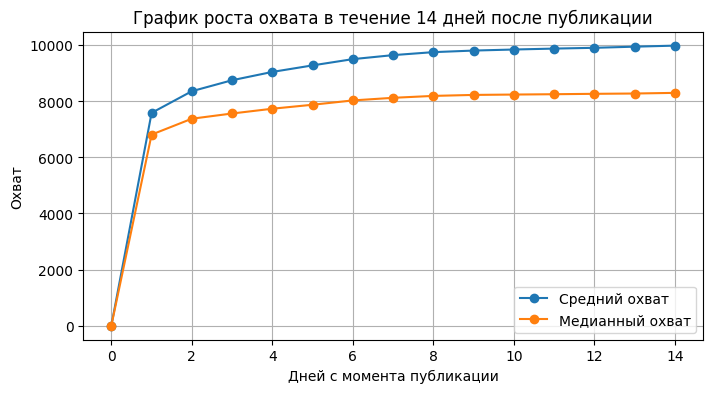

In [21]:
plt.figure(figsize=(8, 4))

plt.plot(mean_views.index, mean_views.values, marker='o', label="Средний охват")
plt.plot(median_views.index, median_views.values, marker='o', label="Медианный охват")

plt.xlabel("Дней с момента публикации")
plt.ylabel("Охват")
plt.title("График роста охвата в течение 14 дней после публикации")
plt.legend()

plt.grid()
plt.show()

Наибольший рост охвата происходит в первый день после публикации. Затем рост продолжается, но становится медленнее, постепенно выходя на плато примерно на 7-8 сутки.

Средний охват выше медианного на всем интервале наблюдений, потому что небольшая часть наиболее успешных статей тянет среднее значение вверх. Поэтому медианное значение лучше характеризует "обычную" статью.

**Добавим на график линии для каждой отдельной статьи**

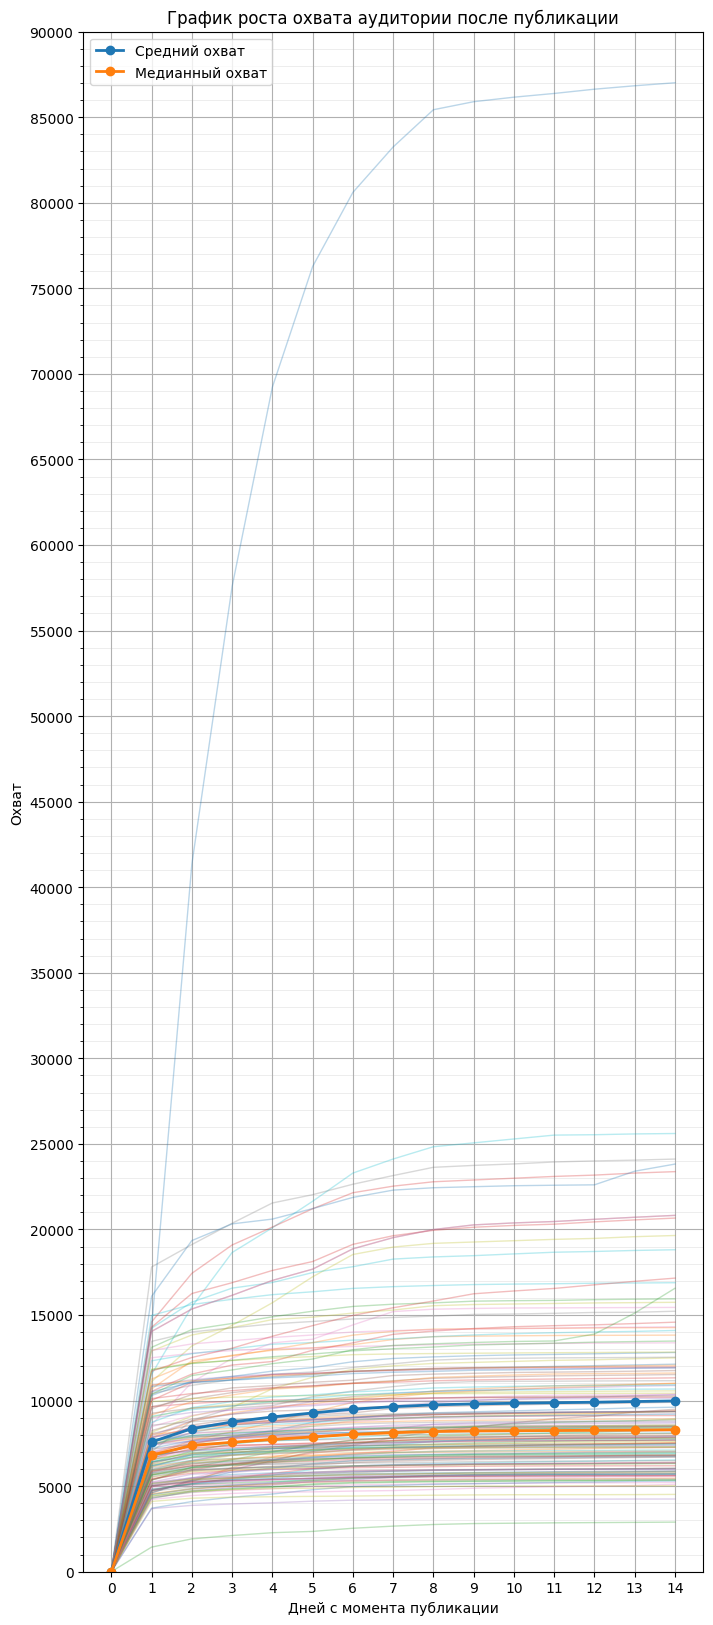

In [22]:
# столбцы с просмотрами
view_cols = [
    "views_day0",
    "views_day1",
    "views_day2",
    "views_day3",
    "views_day4",
    "views_day5",
    "views_day6",
    "views_day7",
    "views_day8",
    "views_day9",
    "views_day10",
    "views_day11",
    "views_day12",
    "views_day13",
    "views_day14",
]

# x координаты
x = np.arange(len(view_cols))

plt.figure(figsize=(8, 20))

# графики всех статей
for _, row in df_14_days.iterrows():

    y = row[view_cols].values.astype(float)

    plt.plot(
        x,
        y,
        alpha=0.3,
        linewidth=1
    )

# средний график
plt.plot(
    mean_views.index,
    mean_views.values,
    marker='o',
    linewidth=2,
    color='C0',
    label="Средний охват"
)

# медианный график
plt.plot(
    median_views.index,
    median_views.values,
    marker='o',
    color='C1',
    linewidth=2,
    label="Медианный охват"
)

plt.xlabel("Дней с момента публикации")
plt.ylabel("Охват")
plt.title("График роста охвата аудитории после публикации")

plt.xticks(x)

ax = plt.gca()

# диапазон оси Y
ax.set_ylim(0, 90000)

# больше подписанных значений по оси Y
ax.set_yticks(np.arange(0, 90001, 5000))

# промежуточные деления
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# основная сетка
ax.grid(True, which="major", linewidth=0.8)

# мелкая сетка
ax.grid(True, which="minor", linewidth=0.4, alpha=0.4)

plt.legend()
plt.show()

На графике видно, что основной рост охвата происходит в первые сутки после публикации. Затем накопление просмотров продолжается, но его темп постепенно снижается. После восьмого дня рост практически заканчивается, только единичные статьи показывают значимый рост на второй неделе после публикации.

Одна статья набрала охват около 87 тысяч, что сильно выбивается из выборки. Остальные статьи набрали охват не более 26 тысяч за первые 14 суток.

**Построим гистограмму и диаграмму размаха**

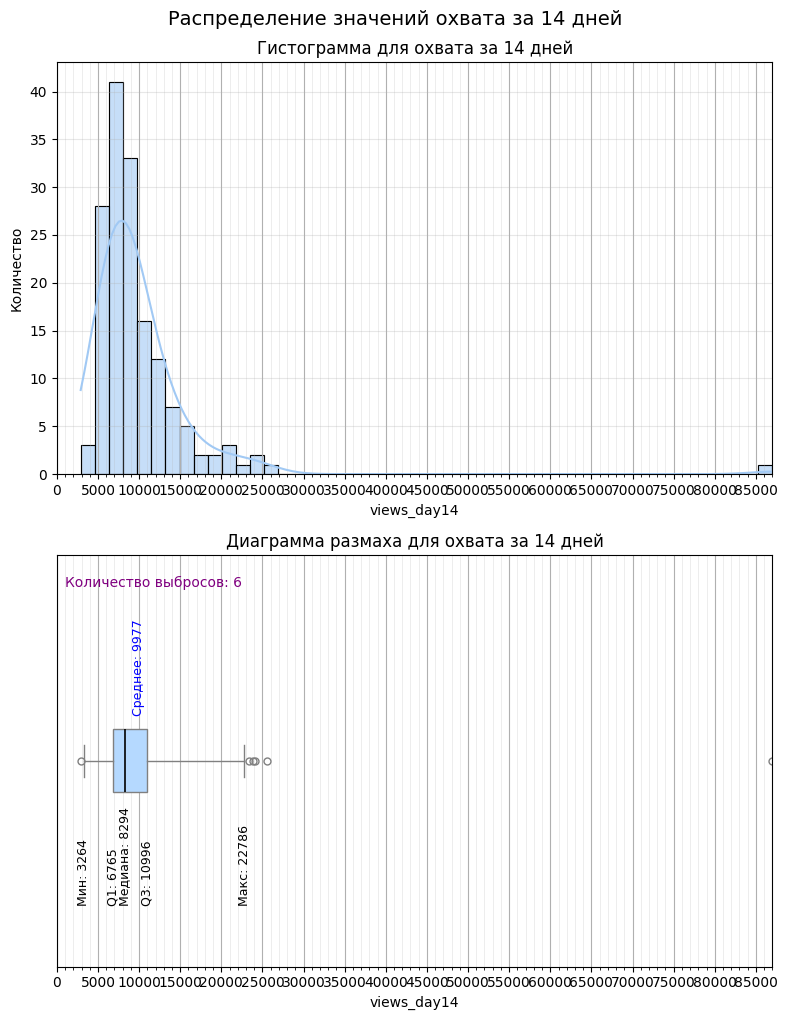

In [23]:
show_hist_boxplot(
    df=df_14_days,
    feature="views_day14",
    bins=49,
    title = "охвата за 14 дней"
)

Выберем масштаб соразмерный основному диапазону значений.

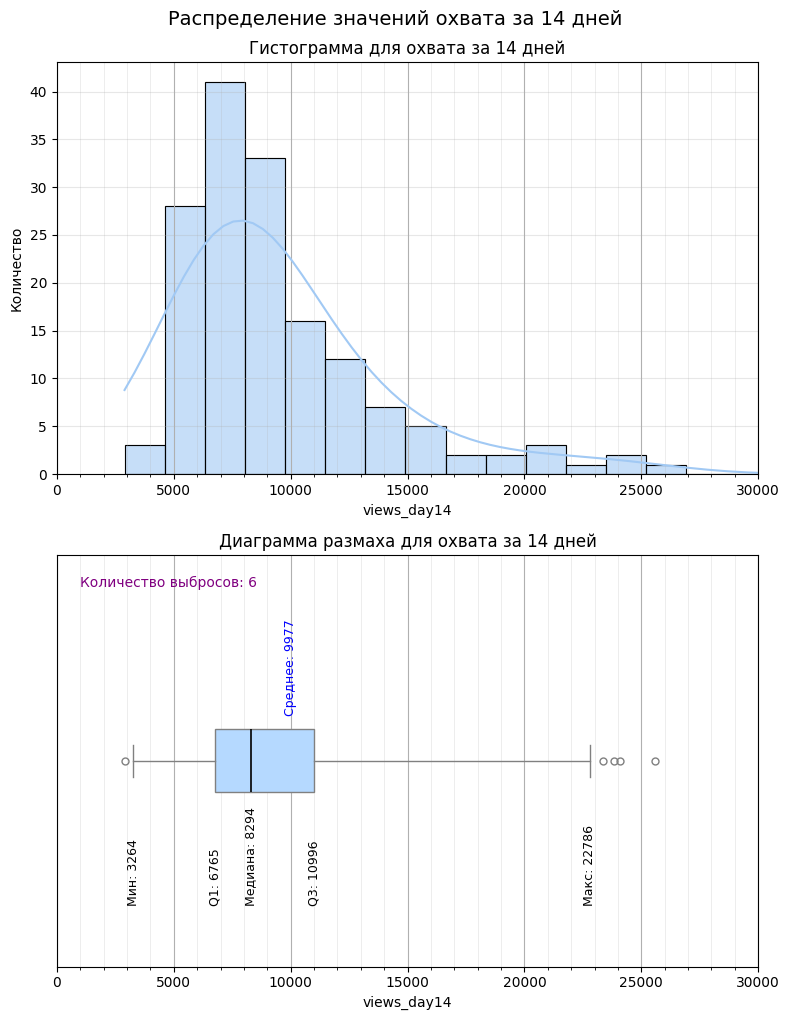

In [24]:
show_hist_boxplot(
    df=df_14_days,
    feature="views_day14",
    max_value=30000,
    bins=49,
    title = "охвата за 14 дней"
)

Распределение имеет выраженный правый скос. 

Межквартильный размах: **от 6765 до 10996**.

Границы основного диапазона значений были рассчитаны с учётом асимметрии распределения. Правило 1,5×IQR применялось не к исходным значениям охвата, а к логарифмированным значениям log(views + 1). 

После обратного преобразования границы основного диапазона значений составили **от 3264 до 22786**. 

Значения за пределами этих границ можно рассматривать как статистические выбросы. В представленной выборке таких выбросов 6 - это статьи, которые набрали заметно меньший или больший охват, чем основная масса публикаций.

**Промежуточный итог:**

Первый день после публикации имеет наибольшее значение для набора охвата аудитории. Для большинства статей рост охвата после 7-8 дня становится незначительным. У половины статей в полученной выборке охват за первые 14 дней находится в диапазоне от 6,8 до 11 тысяч.

<a class='anchor' id="link7"></a>
### 3.2 Анализ охвата статей за 7 дней после публикации

Построим гистограмму и диаграмму размаха для недельных охватов.

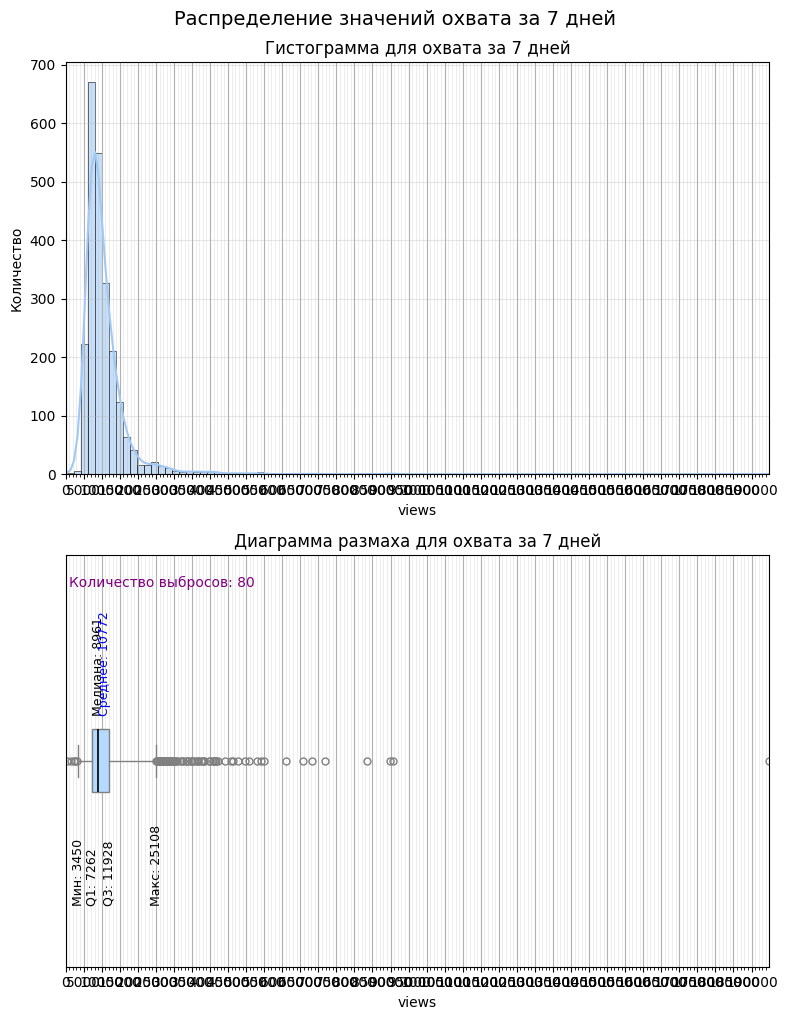

In [25]:
show_hist_boxplot(
    df=df,
    feature="views",
    bins=100,
    title = "охвата за 7 дней"
)

Выберем масштаб соразмерный основному диапазону значений.

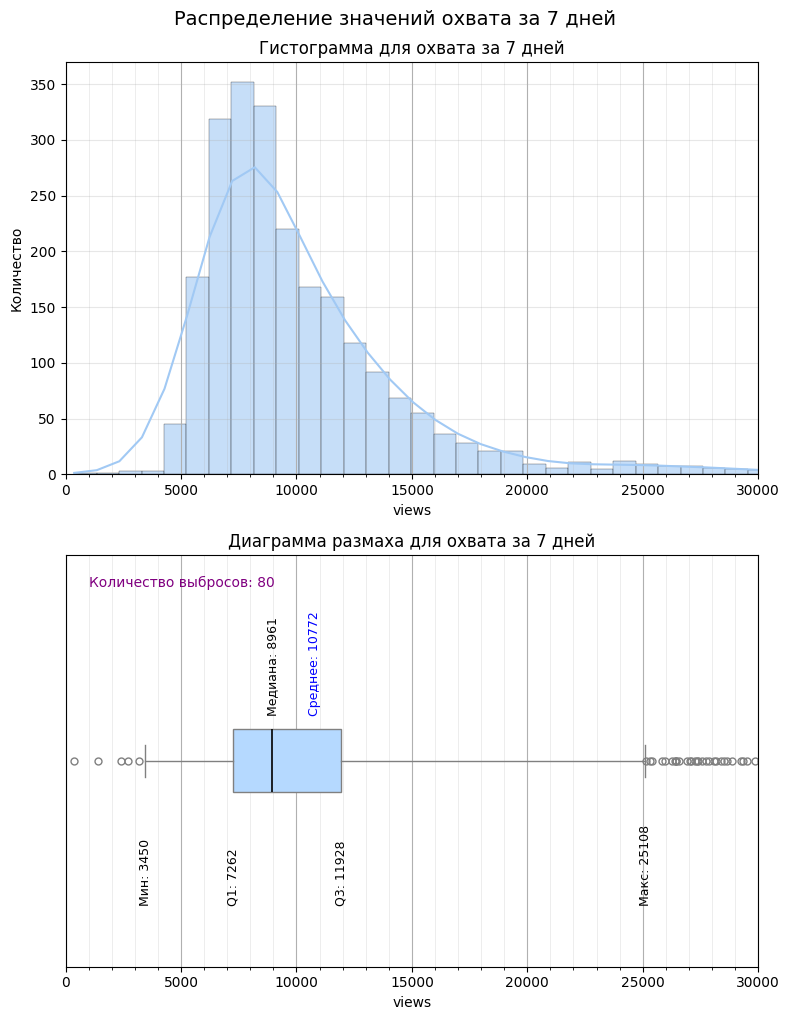

In [26]:
show_hist_boxplot(
    df=df,
    feature="views",
    max_value=30000,
    bins=200,
    title = "охвата за 7 дней"
)

Распределение имеет схожую форму с распределением, полученным в разделе 3.1.

Распределение имеет выраженный правый скос.

Медианный охват: **8961**

Средний охват: **10772**

Межквартильный размах: **от 7262 до 11928**.

Границы основного диапазона значений составили **от 3450 до 25108**. 

Значения за пределами этих границ можно рассматривать как статистические выбросы. В представленной выборке таких выбросов 80 - это статьи, которые набрали заметно меньший или больший охват, чем основная масса публикаций.

**Количество статей по дням недели**

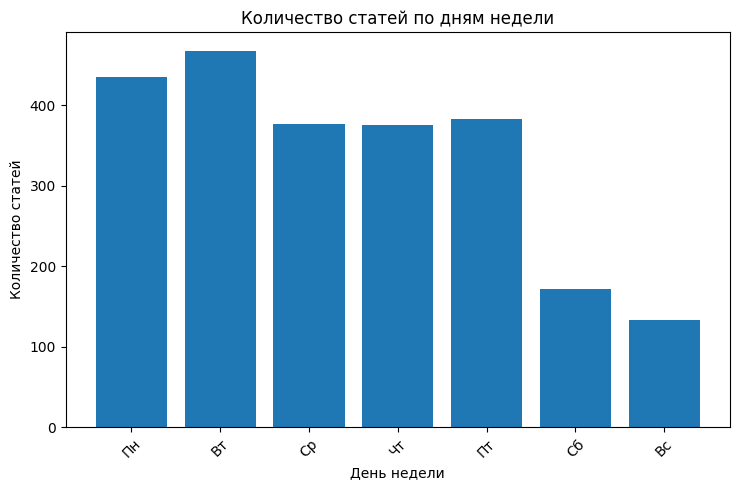

In [27]:
articles_by_weekday = (
    df.groupby(["weekday_num", "weekday"])
    .size()
    .reset_index(name="articles_count")
    .sort_values("weekday_num")
)

plt.figure(figsize=(7.5, 5))
plt.bar(articles_by_weekday["weekday"], articles_by_weekday["articles_count"])
plt.xticks(rotation=45)
plt.title("Количество статей по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество статей")
plt.tight_layout()
plt.show()

В полученной выборке наибольшая публикационная активность наблюдается в будние дни (максимум во вторник). Количество статей, публикуемых в выходные дни, в 2-3 раза меньше.

**Средний охват по дням недели**

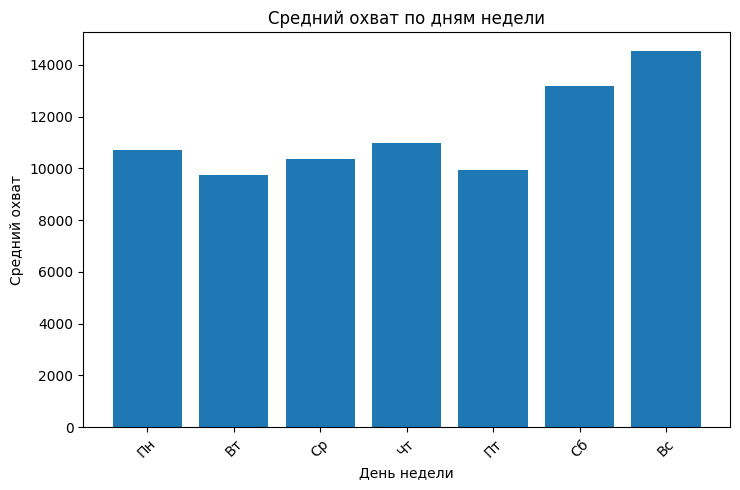

In [28]:
views_by_weekday = (
    df.groupby(["weekday_num", "weekday"])["views"]
    .mean()
    .reset_index(name="mean_views")
    .sort_values("weekday_num")
)

plt.figure(figsize=(7.5, 5))
plt.bar(views_by_weekday["weekday"], views_by_weekday["mean_views"])
plt.xticks(rotation=45)
plt.title("Средний охват по дням недели")
plt.xlabel("День недели")
plt.ylabel("Средний охват")
plt.tight_layout()
plt.show()

**Медианный охват по дням недели**

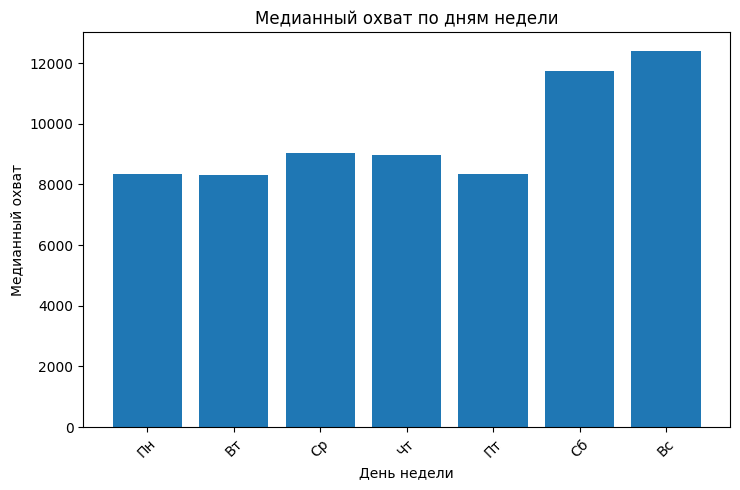

In [29]:
median_views_by_weekday = (
    df.groupby(["weekday_num", "weekday"])["views"]
    .median()
    .reset_index(name="median_views")
    .sort_values("weekday_num")
)

plt.figure(figsize=(7.5, 5))
plt.bar(median_views_by_weekday["weekday"], median_views_by_weekday["median_views"])
plt.xticks(rotation=45)
plt.title("Медианный охват по дням недели")
plt.xlabel("День недели")
plt.ylabel("Медианный охват")
plt.tight_layout()
plt.show()

В имеющейся выборке статьи, публикуемые в выходные дни, набирают больший медианный охват, чем статьи, публикуемые в будние дни.

Медиана лучше подходит для оценки типичного охвата, чем среднее значение, потому что отдельные, наиболее удачные статьи, сильно искажают среднее.

**Связь охвата и количества публикаций по дням недели**

In [30]:
weekday_stats = articles_by_weekday.merge(
    views_by_weekday,
    on=["weekday_num", "weekday"]
)

weekday_stats = weekday_stats.merge(
    median_views_by_weekday,
    on=["weekday_num", "weekday"]
)

weekday_stats

,weekday_num,weekday,articles_count,mean_views,median_views
0,0,Пн,435,10703.055172,8338.0
1,1,Вт,467,9730.432548,8322.0
2,2,Ср,376,10355.106383,9021.5
3,3,Чт,375,10971.637333,8978.0
4,4,Пт,383,9943.394256,8336.0
5,5,Сб,172,13185.883721,11751.0
6,6,Вс,133,14533.894737,12397.0


In [31]:
spearman_corr_mean = weekday_stats["articles_count"].corr(
    weekday_stats["mean_views"],
    method="spearman"
)

print(f"Корреляция Спирмана для количества статей и среднего охвата: {spearman_corr_mean:.3f}")

Корреляция Спирмана для количества статей и среднего охвата: -0.893


In [32]:
spearman_corr_median = weekday_stats["articles_count"].corr(
    weekday_stats["median_views"],
    method="spearman"
)

print(f"Корреляция Спирмана для количества статей и медианного охвата: {spearman_corr_median:.3f}")

Корреляция Спирмана для количества статей и медианного охвата: -0.929


Наблюдается сильная обратная монотонная связь. 

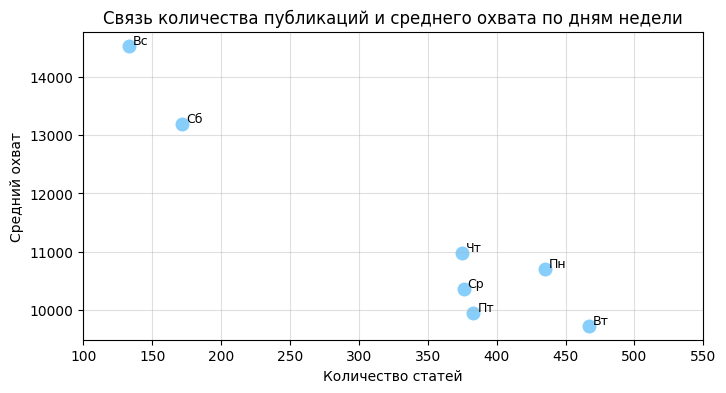

In [33]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=weekday_stats,
    x="articles_count",
    y="mean_views",
    s=120,
    color="lightskyblue"
)

for _, row in weekday_stats.iterrows():
    plt.text(
        row["articles_count"] + 3,
        row["mean_views"] + 30,
        row["weekday"],
        fontsize=9
    )

plt.xlabel("Количество статей")
plt.ylabel("Средний охват")
plt.title("Связь количества публикаций и среднего охвата по дням недели")

plt.xlim(100, 550)
plt.grid(True, alpha=0.4)
plt.show()

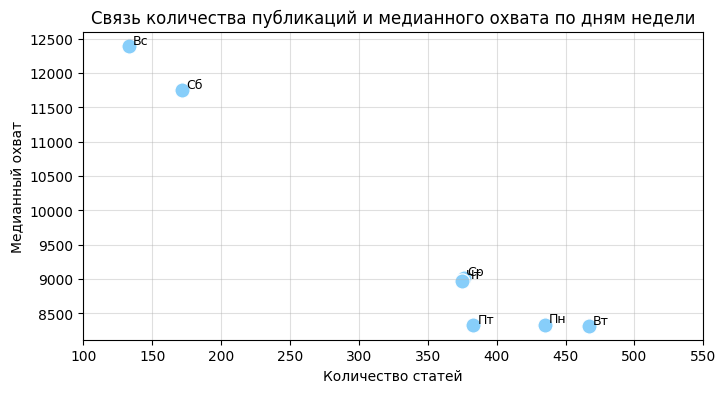

In [34]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=weekday_stats,
    x="articles_count",
    y="median_views",
    s=120,
    color="lightskyblue"
)


for _, row in weekday_stats.iterrows():
    plt.text(
        row["articles_count"] + 3,
        row["median_views"] + 30,
        row["weekday"],
        fontsize=9
    )

plt.xlabel("Количество статей")
plt.ylabel("Медианный охват")
plt.title("Связь количества публикаций и медианного охвата по дням недели")

plt.xlim(100, 550)
plt.grid(True, alpha=0.4)
plt.show()

Полученные значения корреляции указывают на сильную отрицательную связь между количеством публикаций и охватом статьей. При большем числе публикаций медианный и средний охват статей снижаются. Важно учитывать, что расчет проводится всего по 7 точкам. Корреляция охвата и количества статей по дням недели показывает направление связи в данных, но не доказывает устойчивую закономерность.

**Суммарный охват по дням недели**

Посмотрим на суммарный охват по дням недели, перемножив количество опубликованных статей и средний охват. Данный показатель можно рассматривать как характеристику совокупного внимания аудитории к статьям, опубликованным в соответствующий день недели.

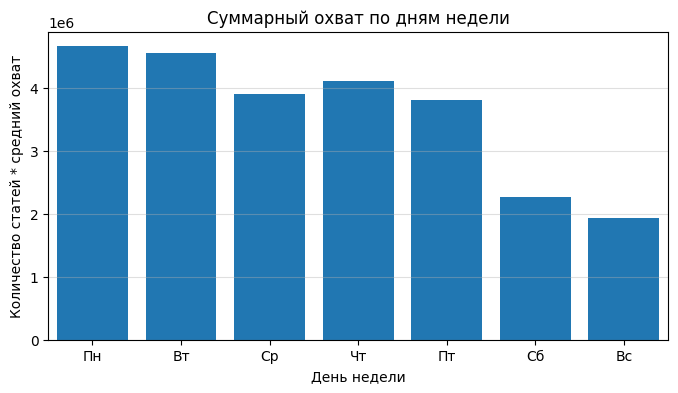

In [35]:
weekday_stats["total_views"] = (
    weekday_stats["articles_count"] * weekday_stats["mean_views"]
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=weekday_stats,
    x="weekday",
    y="total_views",
    color="#097cca"
)

plt.xlabel("День недели")
plt.ylabel("Количество статей * средний охват")
plt.title("Суммарный охват по дням недели")

plt.grid(True, axis="y", alpha=0.4)
plt.show()

За дни наблюдения более высокий суммарный охват был в будние дни. Наибольший в понедельник и вторник. Наименьший суммарный охват у статей, опубликованных в выходные дни. Это связано не с меньшим охватом отдельной статьи, а с меньшим количеством публикаций в выходные дни.

**Количество статей по часам**

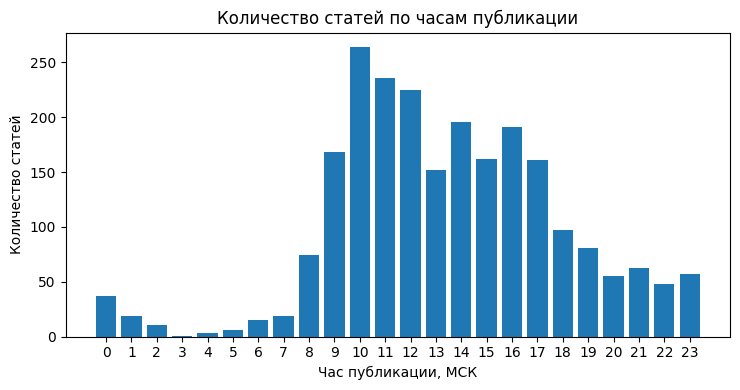

In [36]:
articles_by_hour = (
    df.groupby("hour")
    .size()
    .reset_index(name="articles_count")
    .sort_values("hour")
)

plt.figure(figsize=(7.5, 4))
plt.bar(articles_by_hour["hour"], 
        articles_by_hour["articles_count"],
        color="#1f77b4")
plt.title("Количество статей по часам публикации")
plt.xlabel("Час публикации, МСК")
plt.ylabel("Количество статей")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

Основная публикационная активность происходит в дневное рабочее время (с 9 до 18 часов). 

Наибольшее количество публикаций наблюдается в предобеденное время с 10 до 13 часов.

**Средний охват по часам**

In [37]:
views_by_hour = (
    df.groupby("hour")["views"]
    .mean()
    .reset_index(name="mean_views")
    .sort_values("hour")
)

In [38]:
# На всякий случай гарантируем, что есть все часы 0–23
views_by_hour = (
    views_by_hour
    .set_index("hour")
    .reindex(range(24))
)

In [39]:
# добавим скользящее среднее: час до + текущий + час после
views_by_hour["mean_views_smooth"] = (
    views_by_hour["mean_views"].shift(1).fillna(views_by_hour["mean_views"].iloc[-1]) +
    views_by_hour["mean_views"] +
    views_by_hour["mean_views"].shift(-1).fillna(views_by_hour["mean_views"].iloc[0])
) / 3

views_by_hour = views_by_hour.reset_index()

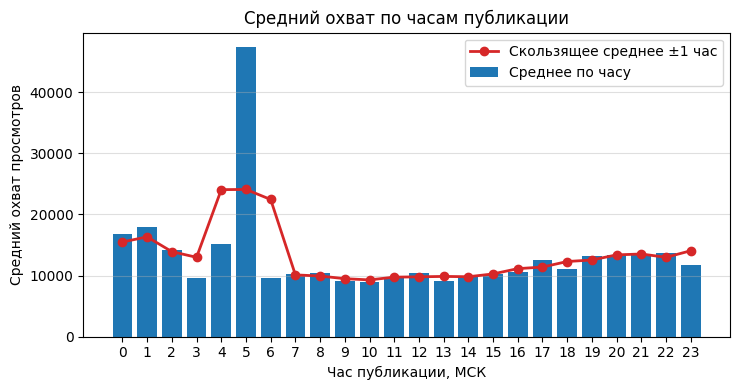

In [40]:
plt.figure(figsize=(7.5, 4))

plt.bar(
    views_by_hour["hour"],
    views_by_hour["mean_views"],
    label="Среднее по часу"
)

plt.plot(
    views_by_hour["hour"],
    views_by_hour["mean_views_smooth"],
    marker="o",
    linewidth=2,
    color="#d62728",
    label="Скользящее среднее ±1 час"
)

plt.title("Средний охват по часам публикации")
plt.xlabel("Час публикации, МСК")
plt.ylabel("Средний охват просмотров")
plt.xticks(range(0, 24))
plt.grid(True, axis="y", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

**Медианный охват по часам**

In [41]:
median_views_by_hour = (
    df.groupby("hour")["views"]
    .median()
    .reset_index(name="median_views")
    .sort_values("hour")
)

In [42]:
# На всякий случай гарантируем, что есть все часы 0–23
median_views_by_hour = (
    median_views_by_hour
    .set_index("hour")
    .reindex(range(24))
)

# добавим скользящее среднее: час до + текущий + час после
median_views_by_hour["median_views_smooth"] = (
    median_views_by_hour["median_views"].shift(1).fillna(median_views_by_hour["median_views"].iloc[-1]) +
    median_views_by_hour["median_views"] +
    median_views_by_hour["median_views"].shift(-1).fillna(median_views_by_hour["median_views"].iloc[0])
) / 3

median_views_by_hour = median_views_by_hour.reset_index()

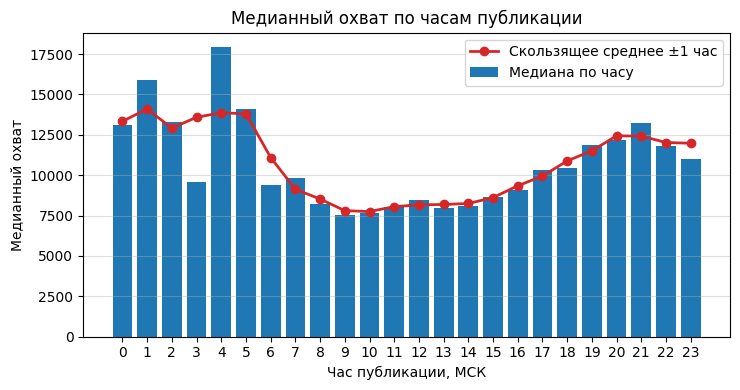

In [43]:
plt.figure(figsize=(7.5, 4))

plt.bar(
    median_views_by_hour["hour"],
    median_views_by_hour["median_views"],
    label="Медиана по часу"
)

plt.plot(
    median_views_by_hour["hour"],
    median_views_by_hour["median_views_smooth"],
    marker="o",
    linewidth=2,
    color="#d62728",
    label="Скользящее среднее ±1 час"
)

plt.title("Медианный охват по часам публикации")
plt.xlabel("Час публикации, МСК")
plt.ylabel("Медианный охват")
plt.xticks(range(0, 24))
plt.grid(True, axis="y", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Статьи, публикуемые в вечернее и ночное время, набирают больший охват.

**Связь охвата и количества публикаций по часам**

In [44]:
hour_stats = articles_by_hour.merge(
    median_views_by_hour,
    on="hour"
)

hour_stats = hour_stats.merge(
    views_by_hour,
    on="hour"
)

Посчитаем корреляцию между количеством статей и охватом

In [45]:
spearman_corr_mean = hour_stats["articles_count"].corr(
    hour_stats["mean_views"],
    method="spearman"
)

print(f"Корреляция Спирмана для количества статей и среднего охвата: {spearman_corr_mean:.3f}")

Корреляция Спирмана для количества статей и среднего охвата: -0.518


In [46]:
spearman_corr_median = hour_stats["articles_count"].corr(
    hour_stats["median_views"],
    method="spearman"
)

print(f"Корреляция Спирмана для количества статей и медианного охвата: {spearman_corr_median:.3f}")

Корреляция Спирмана для количества статей и медианного охвата: -0.735


Для медианного охвата имеется достаточно сильная отрицательная монотонная связь с количеством публикаций.

Построим графики рассеяния для связи охвата с количеством статей по часам публикации.

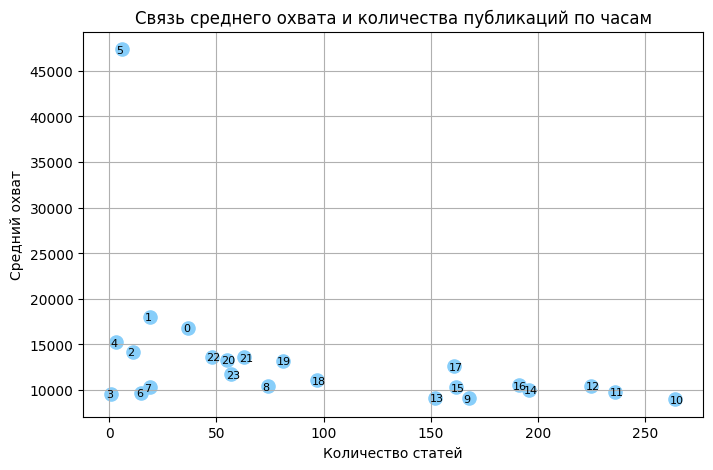

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(
    hour_stats["articles_count"],
    hour_stats["mean_views"],
    s=90,
    color="lightskyblue"
)

for _, row in hour_stats.iterrows():
    plt.annotate(
        int(row["hour"]),
        (row["articles_count"], row["mean_views"]),
        textcoords="offset points",
        xytext=(-4.0, -2.5),
        ha="left",
        fontsize=8
    )

plt.xlabel("Количество статей")
plt.ylabel("Средний охват")
plt.title("Связь среднего охвата и количества публикаций по часам")
plt.grid(True)
plt.show()

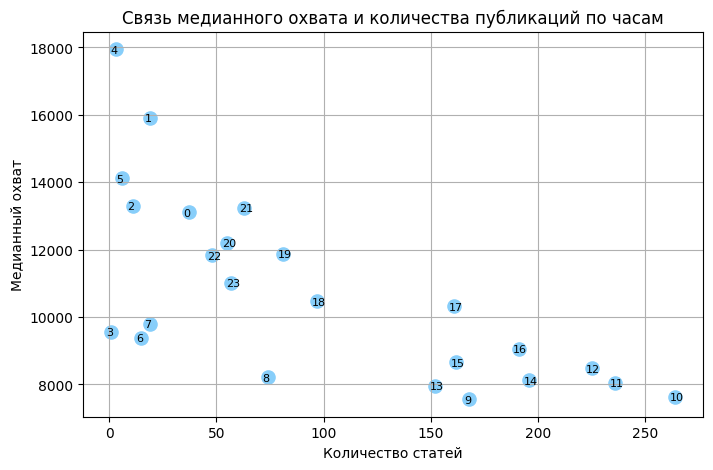

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(
    hour_stats["articles_count"],
    hour_stats["median_views"],
    s=90,
    color="lightskyblue"
)

for _, row in hour_stats.iterrows():
    plt.annotate(
        int(row["hour"]),
        (row["articles_count"], row["median_views"]),
        textcoords="offset points",
        xytext=(-4.0, -2.5),
        ha="left",
        fontsize=8
    )

plt.xlabel("Количество статей")
plt.ylabel("Медианный охват")
plt.title("Связь медианного охвата и количества публикаций по часам")
plt.grid(True)
plt.show()

При увеличении количества публикаций средний и медианный охват снижаются. Однако разброс значений по часам остаётся существенным, поэтому количество публикаций не полностью объясняет различия в охвате.

**Выведем тепловые карты количества публикаций, среднего и медианного охвата для каждого часа недели**

In [49]:
weekly_hour_views = (
    df.groupby(["weekday_num", "weekday", "hour"])
    .agg(
        articles_count=("views", "size"),
        mean_views=("views", "mean"),
        median_views=("views", "median")
    )
    .reset_index()
    .sort_values(["weekday_num", "hour"])
)

In [50]:
weekly_hour_views.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   weekday_num     150 non-null    int32  
 1   weekday         150 non-null    str    
 2   hour            150 non-null    int32  
 3   articles_count  150 non-null    int64  
 4   mean_views      150 non-null    float64
 5   median_views    150 non-null    float64
dtypes: float64(2), int32(2), int64(1), str(1)
memory usage: 6.0 KB


In [51]:
weekly_hour_views.describe(include='all')

,weekday_num,weekday,hour,articles_count,mean_views,median_views
count,150.000000,150,150.000000,150.000000,150.000000,150.000000
unique,NaN,7,NaN,NaN,NaN,NaN
top,NaN,Пн,NaN,NaN,NaN,NaN
freq,NaN,23,NaN,NaN,NaN,NaN
mean,2.933333,NaN,12.420000,15.606667,12997.471282,11816.736667
std,2.035479,NaN,6.772695,14.300184,9300.929084,9280.319104
min,0.000000,NaN,0.000000,1.000000,7368.571429,6702.000000
25%,1.000000,NaN,7.250000,5.000000,9892.294118,8569.250000
50%,3.000000,NaN,13.000000,11.000000,11654.062500,11108.500000
75%,5.000000,NaN,18.000000,24.000000,13689.500000,12620.500000


В полученной таблице представлены данные по 150 сочетаниям дня недели и часа публикации из 168 возможных. За три недели наблюдений 18 часовых интервалов не были покрыты. В эти периоды в выборке не оказалось опубликованных статей.

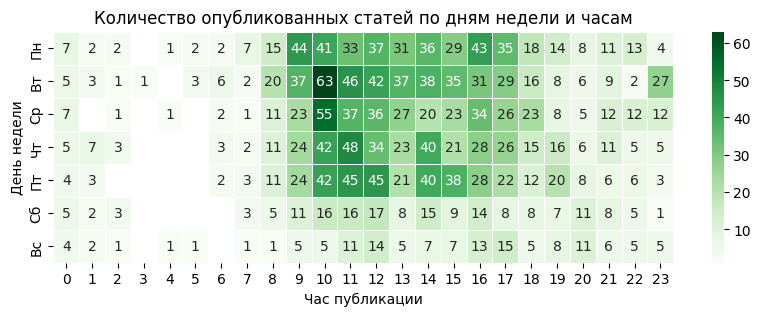

In [52]:
pivot_count = weekly_hour_views.pivot(
    index="weekday",
    columns="hour",
    values="articles_count"
)

pivot_count = pivot_count.loc[["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]]

plt.figure(figsize=(10, 3))

sns.heatmap(
    pivot_count,
    annot=True,
    fmt=".0f",
    cmap="Greens",
    linewidths=0.5,
    annot_kws={"fontsize": 10}
)

plt.title("Количество опубликованных статей по дням недели и часам")
plt.xlabel("Час публикации")
plt.ylabel("День недели")

plt.show()

За дни наблюдения наибольшая публикационная активность была в будние дни в предобеденное время с 9:00 до 13:00 и послеобеденное время с 14:00 до 18:00.
**Самый популярный час недели для публикаций** это: **Вторник с 10:00 до 11:00**.

Также видно, что трёхнедельного периода наблюдений недостаточно для полного покрытия всех сочетаний дня недели и часа публикации. В период времени с 1:00 до 8:00 было опубликовано мало статей. Имеются часовые интервалы с пропусками, когда не было опубликовано ни одной статьи. 

Значения по временным интервалам с малым числом публикаций следует интерпретировать осторожно.

Для построения тепловых карт уберем часовые интервалы, в которые было опубликовано менее трех статей.

In [53]:
weekly_hour_views_short = weekly_hour_views[
    weekly_hour_views["articles_count"] >= 3
].copy()

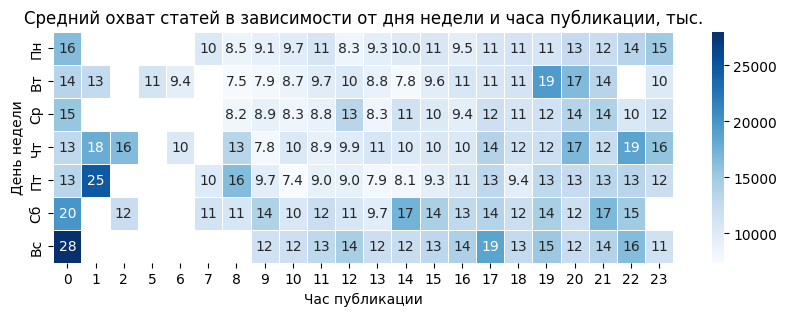

In [54]:
pivot_mean = weekly_hour_views_short.pivot(
    index="weekday",
    columns="hour",
    values="mean_views"
)

# правильный порядок дней недели
pivot_mean = pivot_mean.loc[["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]]

# подписи внутри ячеек в сокращённом виде
annot_labels = pivot_mean.map(format_k)

plt.figure(figsize=(10, 3))

sns.heatmap(
    pivot_mean,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    annot_kws={"fontsize": 10}
)

plt.title("Средний охват статей в зависимости от дня недели и часа публикации, тыс.")
plt.xlabel("Час публикации")
plt.ylabel("День недели")

plt.show()

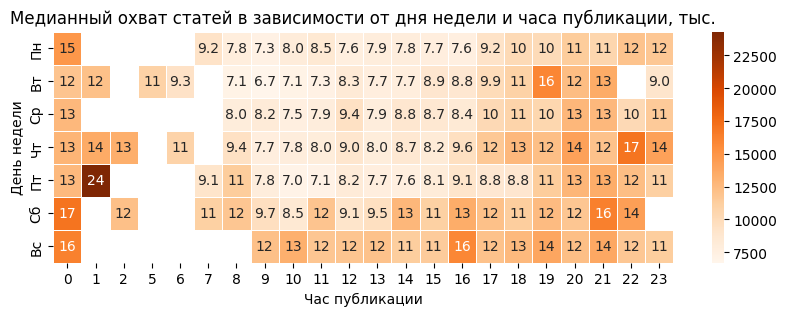

In [55]:
pivot_median = weekly_hour_views_short.pivot(
    index="weekday",
    columns="hour",
    values="median_views"
)

pivot_median = pivot_median.loc[["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]]

# подписи внутри ячеек в сокращённом виде
annot_labels = pivot_median.map(format_k)


plt.figure(figsize=(10, 3))

sns.heatmap(
    pivot_median,
    annot=annot_labels,
    fmt="",
    cmap="Oranges",
    linewidths=0.5,
    annot_kws={"fontsize": 10}
)

plt.title("Медианный охват статей в зависимости от дня недели и часа публикации, тыс.")
plt.xlabel("Час публикации")
plt.ylabel("День недели")

plt.show()

Имеющиеся данные показывают, что статьи, опубликованные в дневное время в будние дни, набирают относительно меньший охват. В большинстве часовых интервалов с 8:00 до 17:00 в будние дни медианный охват статей не превышает 10 тыс. читателей.

В то же время статьи, опубликованные после 19:00 в будние дни, а также в выходные дни, для большинства часовых интервалов имеют медианный охват более 10 тыс. 

Время с 1:00 до 8:00 по будним дням также может быть перспективным, однако в текущей выборке по каждому отдельному часовому интервалу в этот период времени мало наблюдений.

Объединим временные промежутки в ночные и ранние утренние часы и посмотрим статистику охвата.

In [56]:
night_stats = (
    df[
        (df["hour"] >= 1) &
        (df["hour"] < 8)
    ]
    .agg(
        articles_count=("views", "size"),
        mean_views=("views", "mean"),
        median_views=("views", "median"),
    )
)

night_stats

,views
articles_count,74.000000
mean_views,15909.391892
median_views,11607.000000


In [57]:
print(f"Средний охват с 1:00 до 8:00:    {night_stats["views"]['mean_views']:.0f}")
print(f"Медианный охват с 1:00 до 8:00:  {night_stats["views"]['median_views']:.0f}")

Средний охват с 1:00 до 8:00:    15909
Медианный охват с 1:00 до 8:00:  11607


Медианный охват статей в период с 1:00 до 8:00 примерно соотвеетствует медианному охвату статей в другие нерабочие часы.

Проведем агрегацию временных промежутков по двум кластерам:
- Рабочее время: Будние дни с 8:00 до 19:00
- Нерабочее время: Будние дни с 19:00 до 8:00 + Выходные дни

In [58]:
df_clustered = df.copy()

# Будние дни
is_weekday = df_clustered["weekday_num"].between(0, 4)

# Кластер 1: будние дни с 8:00 до 19:00
work_mask = (
    is_weekday &
    (df_clustered["hour"] >= 8) &
    (df_clustered["hour"] < 19)
)

# Кластер 2: будние дни с 19:00 до 8:00 + выходные дни
non_work_mask = (
    (
        is_weekday &
        (
            (df_clustered["hour"] >= 19) |
            (df_clustered["hour"] < 8)
        )
    )
    |
    (~is_weekday)
)

df_clustered["time_cluster"] = np.where(
    work_mask,
    "Будни 8:00–19:00",
    "Будни 19:00–8:00 + Выходные"
)

work_views = df_clustered.loc[
    df_clustered["time_cluster"] == "Будни 8:00–19:00",
    "views"
].values

non_work_views = df_clustered.loc[
    df_clustered["time_cluster"] == "Будни 19:00–8:00 + Выходные",
    "views"
].values

**Проверим гипотезу о том, что медианный охват статей, опубликованных в нерабочее время, выше медианного охвата статей, опубликованных в рабочее время.**

**Нулевая гипотеза H0:** медианный охват статей, опубликованных в нерабочее время, не выше медианного охвата статей, опубликованных в рабочее время.

**Альтернативная гипотеза H1:** медианный охват статей, опубликованных в нерабочее время, выше медианного охвата статей, опубликованных в рабочее время.

Для проверки гипотезы используем перестановочный тест, который позволит оценить p-value (вероятность получить разницу медиан не меньше наблюдаемой при справедливости нулевой гипотезы).

Доверительный интервал разницы медиан оценим через bootstrap.

Такой подход выбран потому, что распределение охвата статей асимметрично и содержит выбросы. В таких условиях медиана лучше отражает типичный охват статьи, чем среднее значение, а классический t-test, проверяющий различия средних, может быть менее точен.

In [59]:
alpha = 0.01
n_permutations = 10000

rng_perm = np.random.default_rng(42)

# Наблюдаемая разница медиан
observed_diff = np.median(non_work_views) - np.median(work_views)

combined = np.concatenate([work_views, non_work_views])
n_work = len(work_views)

permutation_diffs = []

for _ in range(n_permutations):
    shuffled = rng_perm.permutation(combined)

    work_sample = shuffled[:n_work]
    non_work_sample = shuffled[n_work:]

    diff = np.median(non_work_sample) - np.median(work_sample)
    permutation_diffs.append(diff)

permutation_diffs = np.array(permutation_diffs)

# Односторонний p-value:
# насколько часто при случайном перемешивании разница медиан получается не меньше наблюдаемой с поправкой +1
#p_value = np.mean(permutation_diffs >= observed_diff)
p_value = (np.sum(permutation_diffs >= observed_diff) + 1) / (n_permutations + 1)

print(f"Медианный охват в рабочее время: {np.median(work_views):.0f}")
print(f"Медианный охват в нерабочее время: {np.median(non_work_views):.0f}")
print(f"Наблюдаемая разница медиан: {observed_diff:.0f}")
print(f"p-value перестановочного теста: {p_value:.4f}")

if p_value < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Нет оснований отвергнуть нулевую гипотезу")

Медианный охват в рабочее время: 8162
Медианный охват в нерабочее время: 11944
Наблюдаемая разница медиан: 3782
p-value перестановочного теста: 0.0001
Отвергаем нулевую гипотезу


Результат теста говорит о том, что если бы на самом деле различий между рабочим и нерабочим временем не было, то вероятность случайно получить разницу медиан 3782 или больше составила бы менее 0,01%.

In [60]:
n_bootstrap = 10000

rng_boot = np.random.default_rng(43)

bootstrap_diffs = []

for _ in range(n_bootstrap):
    work_sample = rng_boot.choice(
        work_views,
        size=len(work_views),
        replace=True
    )

    non_work_sample = rng_boot.choice(
        non_work_views,
        size=len(non_work_views),
        replace=True
    )

    diff = np.median(non_work_sample) - np.median(work_sample)
    bootstrap_diffs.append(diff)

bootstrap_diffs = np.array(bootstrap_diffs)

ci_lower = np.percentile(bootstrap_diffs, 0.5)
ci_upper = np.percentile(bootstrap_diffs, 99.5)

print(f"99% bootstrap-доверительный интервал разницы медиан: [{ci_lower:.0f}; {ci_upper:.0f}]")

if ci_lower > 0:
    print("Доверительный интервал полностью выше нуля")
else:
    print("Доверительный интервал пересекает ноль")

99% bootstrap-доверительный интервал разницы медиан: [3304; 4209]
Доверительный интервал полностью выше нуля


На основе имеющихся данных есть основания отвергнуть нулевую гипотезу в пользу альтернативной.

В рассматриваемой выборке медианный охват статей, опубликованных в нерабочие часы, статистически значимо выше, чем медианный охват статей, опубликованных в рабочие часы.

In [61]:
print(
    f"За время наблюдения статьи, публикуемые в нерабочие часы (Будние дни с 19:00 до 8:00 + Выходные дни), " 
    f"набирали в {np.median(non_work_views) / np.median(work_views):.2f} раза больший медианный охват, чем статьи, " 
    f"опубликованные в  рабочие часы (Будни 8:00–19:00)."
)

За время наблюдения статьи, публикуемые в нерабочие часы (Будние дни с 19:00 до 8:00 + Выходные дни), набирали в 1.46 раза больший медианный охват, чем статьи, опубликованные в  рабочие часы (Будни 8:00–19:00).


**Промежуточный итог:**

Анализ недельных охватов показал:

- **медианный охват** статьи за неделю составляет: **8961**
- **средний охват**: **10772**
- **межквартильный размах**: **от 7262 до 11928**.
- **границы основного диапазона** значений составили **от 3450 до 25108**.
- **наибольшая публикационная активность** наблюдается в рабочие часы: **с 9:00 до 18:00 в будние дни**
- прослеживается обратная корреляция между количеством публикуемых статей и охватом.
- **больший охват** набирают статьи, публикуемые в нерабочие часы (**будние дни с 19:00 до 8:00 + выходные дни**),
- медианный охват таких статей в **1,46** раза больше, чем охват статей, публикуемых в рабочее время (с 8:00 до 19:00 по будним дням). 

<a class='anchor' id="link8"></a>
## Заключение

В имеющейся выборке **больший медианный охват** наблюдается у статей, опубликованных:
- **в будние дни с 19:00 до 8:00**
- **в выходные дни**

**Дневные рабочие часы**, напротив, показывают **более низкий медианный охват**.

Одним из возможных объяснений может быть меньшая конкуренция за внимание читателей в вечернее время и выходные дни. Так как статья набирает большую часть охвата именно в первое время после публикации, количество соседних публикаций в первые часы может влиять на результат статьи.

**Ограничения результатов**

При интерпретации результатов необходимо учитывать, что:
- Анализ выполнен на выборке за три недели. В выборке нет данных за некоторые ночные часы. Многие часы представлены малым количеством статей, что влияет на точность статистики. 
- Результаты отражают текущие поведенческие паттерны аудитории и могут изменяться со временем.
- В анализе участвуют только новые статьи на дистанции примерно 7 дней с даты публикации, что не отражает долгосрочные тенденции.
- Не учитываются популярность автора, наличие подписчиков, названия статей и множество других параметров, которые могут влиять на охват.

**Рекомендации**

- Расширить период наблюдения.
- Собрать больше данных по ночным и ранним утренним часам.

Это позволит надёжнее оценить охват в периоды с низкой публикационной активностью и снизить влияние случайных выбросов.

- Провести аналогичное исследование в разные периоды года.

Это позволит проверить, сохраняются ли выявленные закономерности в течение года или они характерны только для рассматриваемого периода наблюдений.